## MobileNetV2 model 
---
![mobnv2](../picture/MobileNetV2.png)
MobileNetV2 is a convolutional neural network architecture that seeks to perform well on mobile devices. It is based on an inverted residual structure where the residual connections are between the bottleneck layers. The intermediate expansion layer uses lightweight depthwise convolutions to filter features as a source of non-linearity. As a whole, the architecture of MobileNetV2 contains the initial fully convolution layer with 32 filters, followed by 19 residual bottleneck layers. [Source](https://paperswithcode.com/method/mobilenetv2#:~:text=MobileNetV2%20is%20a%20convolutional%20neural,are%20between%20the%20bottleneck%20layers.)

In [2]:
# Import library
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image

# Open file
import os
import PIL
from random import seed
# Model CNN (Deep learning network)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense,\
GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
# Create function plot loss function and accuracy score graph
def plot_graph(model_values):
    ''' 
    Input : Model_values of keras.callbacks.History
    Return : Graph of Loss function and accuracy score between training dataset and vaildation dataset
    '''
    # Subplots
    fig, ax = plt.subplots(1, 2, figsize=(14,5))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(model_values.history['loss'], label='Training Loss');
    plt.plot(model_values.history['val_loss'], label='Testing Loss');
    plt.legend(fontsize=12, loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss');
    
    # Plot MSE
    plt.subplot(1, 2, 2)
    
    plt.plot(model_values.history['accuracy'], label='Training Accuracy')
    plt.plot(model_values.history['val_accuracy'], label='Validation Accuracy')
    
    plt.legend(fontsize=12, loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy');

### 00 First, check GPU.
---

In [4]:
# https://www.tensorflow.org/guide/keras/sequential_model
# Due to we use Keras Sequential API, 
# We want to check GPU first before training our model for 
# impore efficiency and reduce time. 
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 12048677241943364650
xla_global_id: -1
]


### 01 Open dataset 
---

In [5]:
import os
import shutil
import random

# Define dataset path
base_dir = r"D:\Data_Set"

# Define train, valid, and test directories
train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")
test_dir = os.path.join(base_dir, "test")

# Create train, valid, and test folders if they don’t exist
for folder in [train_dir, valid_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)

# List of class folders (cocci, healthy, ncd, salmo)
class_names = ["cocci", "healthy", "ncd", "salmo"]

# Split ratios
train_ratio = 0.7
valid_ratio = 0.2
test_ratio = 0.1

# Move images into train, valid, and test folders
for class_name in class_names:
    class_path = os.path.join(base_dir, class_name)
    
    if not os.path.exists(class_path):
        print(f"Skipping {class_name}, folder not found!")
        continue
    
    # Get all image files in class folder
    images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    
    # Shuffle images for random distribution
    random.shuffle(images)

    # Compute split sizes
    train_size = int(len(images) * train_ratio)
    valid_size = int(len(images) * valid_ratio)

    # Split dataset
    train_images = images[:train_size]
    valid_images = images[train_size:train_size + valid_size]
    test_images = images[train_size + valid_size:]

    # Create class folders in train, valid, test
    for folder in [train_dir, valid_dir, test_dir]:
        os.makedirs(os.path.join(folder, class_name), exist_ok=True)

    # Move images to respective folders
    for img in train_images:
        shutil.move(os.path.join(class_path, img), os.path.join(train_dir, class_name, img))
    
    for img in valid_images:
        shutil.move(os.path.join(class_path, img), os.path.join(valid_dir, class_name, img))
    
    for img in test_images:
        shutil.move(os.path.join(class_path, img), os.path.join(test_dir, class_name, img))

    # Remove empty original class folders
    os.rmdir(class_path)

print("✅ Data restructuring complete!")


Skipping cocci, folder not found!
Skipping healthy, folder not found!
Skipping ncd, folder not found!
Skipping salmo, folder not found!
✅ Data restructuring complete!


### 02 Preprocessing image dataset 
---

In [6]:
# Set parameter of image 
# https://github.com/keras-team/keras/issues/8090#issuecomment-335155737
batch_size = 50 # Set the batch size for epoch cycle
img_height = 128 # Set the height of the picture
img_width = 128 # Set the width of the picture

# Rescale pixel to reduce image size before using in model
data_gen_train = ImageDataGenerator(rescale=1/255.)
data_gen_valid = ImageDataGenerator(rescale=1/255.)
data_gen_test = ImageDataGenerator(rescale=1/255.)

In [7]:
# Create training dataset 
train_dataset = data_gen_train.flow_from_directory(train_dir,
                                                   class_mode="categorical",
                                                   target_size=(img_height, img_width),
                                                   batch_size=batch_size)
 

# Create validation dataset 
valid_dataset = data_gen_valid.flow_from_directory(valid_dir,
                                                   class_mode="categorical",
                                                   target_size=(img_height, img_width),
                                                   batch_size=batch_size)

# Create testing dataset 
test_dataset = data_gen_test.flow_from_directory(test_dir,
                                                   class_mode="categorical",
                                                   target_size=(img_height, img_width),
                                                   batch_size=batch_size)



Found 8478 images belonging to 4 classes.
Found 2421 images belonging to 4 classes.
Found 1215 images belonging to 4 classes.


---

### 03 MobileNetV2 model training 
---

#### Transfer learning

In [8]:
# https://keras.io/api/applications/mobilenet/#mobilenetv2-function
# import MobileNetV2 model form keras API
# set input size of image of trianing is 128x128 (smallest size of MobileNetV2)
# due to we want to use transfer learning process 
# we must add `include_top=False` because we wan to add our input data 
# we decide default weigh for mode
mobv2_model = tf.keras.applications.MobileNetV2(input_shape=(128,128,3),
                                                include_top=False, # Transfer learning
                                                weights="imagenet")

In [9]:
# model summary
# Total params: 2,257,984
# Trainable params: 2,223,872
# Non-trainable params: 34,112
mobv2_model.summary()

Model: "mobilenetv2_1.00_128"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 64, 64, 32)   864         ['input_1[0][0]']                
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 64, 64, 32)   128         ['Conv1[0][0]']                  
                                                                                                  
 Conv1_relu (ReLU)              (None, 64, 64, 32)   0           ['bn_Conv1[0][

                                                                                                  
 block_14_depthwise_relu (ReLU)  (None, 4, 4, 960)   0           ['block_14_depthwise_BN[0][0]']  
                                                                                                  
 block_14_project (Conv2D)      (None, 4, 4, 160)    153600      ['block_14_depthwise_relu[0][0]']
                                                                                                  
 block_14_project_BN (BatchNorm  (None, 4, 4, 160)   640         ['block_14_project[0][0]']       
 alization)                                                                                       
                                                                                                  
 block_14_add (Add)             (None, 4, 4, 160)    0           ['block_13_project_BN[0][0]',    
                                                                  'block_14_project_BN[0][0]']    
          

In [10]:
# fix weights and bias 
# train specifically custom head
mobv2_model.trainable=False

#### Add custom head and output layers 

In [11]:
# Create output layer 
# We have 4 classes in our output we decide using activation="softmax" 
# for multi classification.
# Before output layer we decide use GlobalAveragePooling2D as 
# one type of flatten layer.
average_pooling_layer = tf.keras.layers.GlobalAveragePooling2D()(mobv2_model.output) # flatten
prediction_layer = tf.keras.layers.Dense(units=4, activation="softmax")(average_pooling_layer)

In [12]:
# Add Input layer and output layer 
model = tf.keras.models.Model(inputs=mobv2_model.input, 
                                    outputs=prediction_layer)

In [13]:
# Total params: 2,263,108
# Trainable params: 5,124 # add input layers and  output layers
# Non-trainable params: 2,257,984 --> fix layers
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 64, 64, 32)   864         ['input_1[0][0]']                
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 64, 64, 32)   128         ['Conv1[0][0]']                  
                                                                                                  
 Conv1_relu (ReLU)              (None, 64, 64, 32)   0           ['bn_Conv1[0][0]']           

                                                                                                  
 block_14_depthwise_relu (ReLU)  (None, 4, 4, 960)   0           ['block_14_depthwise_BN[0][0]']  
                                                                                                  
 block_14_project (Conv2D)      (None, 4, 4, 160)    153600      ['block_14_depthwise_relu[0][0]']
                                                                                                  
 block_14_project_BN (BatchNorm  (None, 4, 4, 160)   640         ['block_14_project[0][0]']       
 alization)                                                                                       
                                                                                                  
 block_14_add (Add)             (None, 4, 4, 160)    0           ['block_13_project_BN[0][0]',    
                                                                  'block_14_project_BN[0][0]']    
          

In [14]:
# Compile the model         
model.compile(loss="categorical_crossentropy", 
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

In [15]:
import os
import tensorflow as tf

# Define a safe absolute path to store checkpoints (Modify this if needed)
base_dir = os.path.expanduser("~/deep_learning_checkpoints")  # Creates a folder in the user's home directory
checkpoint_path = os.path.join(base_dir, "mobilenetv2_cp.weights.h5")

# Ensure the checkpoint directory exists
os.makedirs(base_dir, exist_ok=True)  # Create only if it doesn't exist

# Create a callback that saves the model's weights
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                 save_weights_only=True,  # Saving only weights
                                                 verbose=1)

print(f"Checkpoint will be saved at: {checkpoint_path}")

Checkpoint will be saved at: C:\Users\Muhammad Salman/deep_learning_checkpoints\mobilenetv2_cp.weights.h5


In [16]:
from PIL import ImageFile

# Allow truncated images to be loaded instead of causing an error
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Training model
# Make sure checkpoint_path is correctly saved
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=valid_dataset,
    callbacks=[cp_callback]
)

Epoch 1/5
170/170 [==============================] - ETA: 0s - loss: 0.3109 - accuracy: 0.8897   
Epoch 1: saving model to C:\Users\Muhammad Salman/deep_learning_checkpoints\mobilenetv2_cp.weights.h5
170/170 [==============================] - 2215s 13s/step - loss: 0.3109 - accuracy: 0.8897 - val_loss: 0.1927 - val_accuracy: 0.9393
Epoch 2/5
170/170 [==============================] - ETA: 0s - loss: 0.1456 - accuracy: 0.9493   
Epoch 2: saving model to C:\Users\Muhammad Salman/deep_learning_checkpoints\mobilenetv2_cp.weights.h5
170/170 [==============================] - 2110s 12s/step - loss: 0.1456 - accuracy: 0.9493 - val_loss: 0.1453 - val_accuracy: 0.9537
Epoch 3/5
170/170 [==============================] - ETA: 0s - loss: 0.1116 - accuracy: 0.9601   
Epoch 3: saving model to C:\Users\Muhammad Salman/deep_learning_checkpoints\mobilenetv2_cp.weights.h5
170/170 [==============================] - 2052s 12s/step - loss: 0.1116 - accuracy: 0.9601 - val_loss: 0.1240 - val_accuracy: 0.959

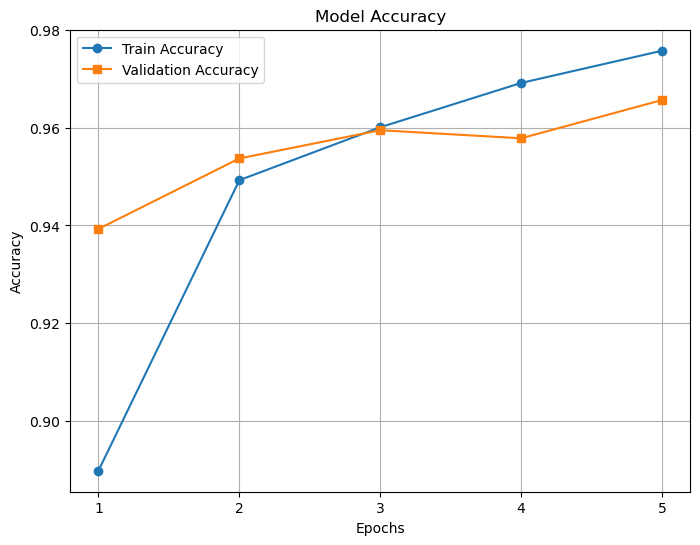

In [17]:
# plot graph 
import matplotlib.pyplot as plt

def plot_graph(history):
    # Ensure history contains accuracy data
    if 'accuracy' not in history.history or 'val_accuracy' not in history.history:
        print("Error: Accuracy data not found in history.")
        return

    epochs_range = range(1, len(history.history['accuracy']) + 1)  # Generate epoch numbers

    plt.figure(figsize=(8, 6))

    # Plot training & validation accuracy
    plt.plot(epochs_range, history.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(epochs_range, history.history['val_accuracy'], label='Validation Accuracy', marker='s')

    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.xticks(epochs_range)  # Ensure epoch numbers are displayed correctly
    plt.legend()
    plt.grid(True)

    # Show the graph
    plt.show()

# Call the function to display the graph
plot_graph(history)


In [18]:
# create dataframe to save in .csv file
hist_df = pd.DataFrame(history.history) 
hist_df.head()


,loss,accuracy,val_loss,val_accuracy
0,0.310917,0.889715,0.192732,0.939281
1,0.145594,0.949281,0.145297,0.953738
2,0.111647,0.960132,0.124014,0.959521
3,0.091090,0.969214,0.115671,0.957869
4,0.077371,0.975820,0.104783,0.965717


In [19]:
import os
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

# Define the model (Ensure model is created before saving)
model = MobileNetV2(weights=None, input_shape=(224, 224, 3), classes=4)  # Modify as needed
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Define model save path in a safe location
model_path = "D:/mobilenetv2_model.h5"

# Ensure directory exists
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Save model
model.save(model_path)

print(f"Model saved successfully at: {model_path}")


Model saved successfully at: D:/mobilenetv2_model.h5


In [20]:
import os
import pandas as pd

# Define history save path
hist_csv_file = "D:/mobilenetv2_history/history_mobilenetv2.csv"

# Ensure the directory exists
os.makedirs(os.path.dirname(hist_csv_file), exist_ok=True)

# Convert history to DataFrame (if not already a DataFrame)
hist_df = pd.DataFrame(history.history)

# Save history to CSV
hist_df.to_csv(hist_csv_file, index=False)

print(f"History saved successfully at {hist_csv_file}")

History saved successfully at D:/mobilenetv2_history/history_mobilenetv2.csv


---